<a href="https://colab.research.google.com/github/SyncFusion-1138/Report/blob/main/notebooks/heart_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# ============================================================
# 心脏病风险预测与可解释性分析 - Step 1: 数据加载与EDA
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体（Colab环境）
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 1. 加载数据
df = pd.read_csv('/content/heart.csv')

# 检查重复行
print(f"原始数据行数: {len(df)}")
print(f"重复行数: {df.duplicated().sum()}")
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"去重后行数: {len(df_clean)}")
print(f"去重后类别分布:\n{df_clean['target'].value_counts()}")


print("=== 数据基本信息 ===")
print(f"数据集形状: {df.shape}")
print(f"\n各列数据类型:\n{df.dtypes}")
print(f"\n缺失值统计:\n{df.isnull().sum()}")
print(f"\n目标变量分布:\n{df['target'].value_counts()}")
print(f"\n类别比例:\n{df['target'].value_counts(normalize=True).round(4)}")

df.head()


原始数据行数: 1025
重复行数: 723
去重后行数: 302
去重后类别分布:
target
1    164
0    138
Name: count, dtype: int64
=== 数据基本信息 ===
数据集形状: (1025, 14)

各列数据类型:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

缺失值统计:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

目标变量分布:
target
1    526
0    499
Name: count, dtype: int64

类别比例:
target
1    0.5132
0    0.4868
Name: proportion, dtype: float64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


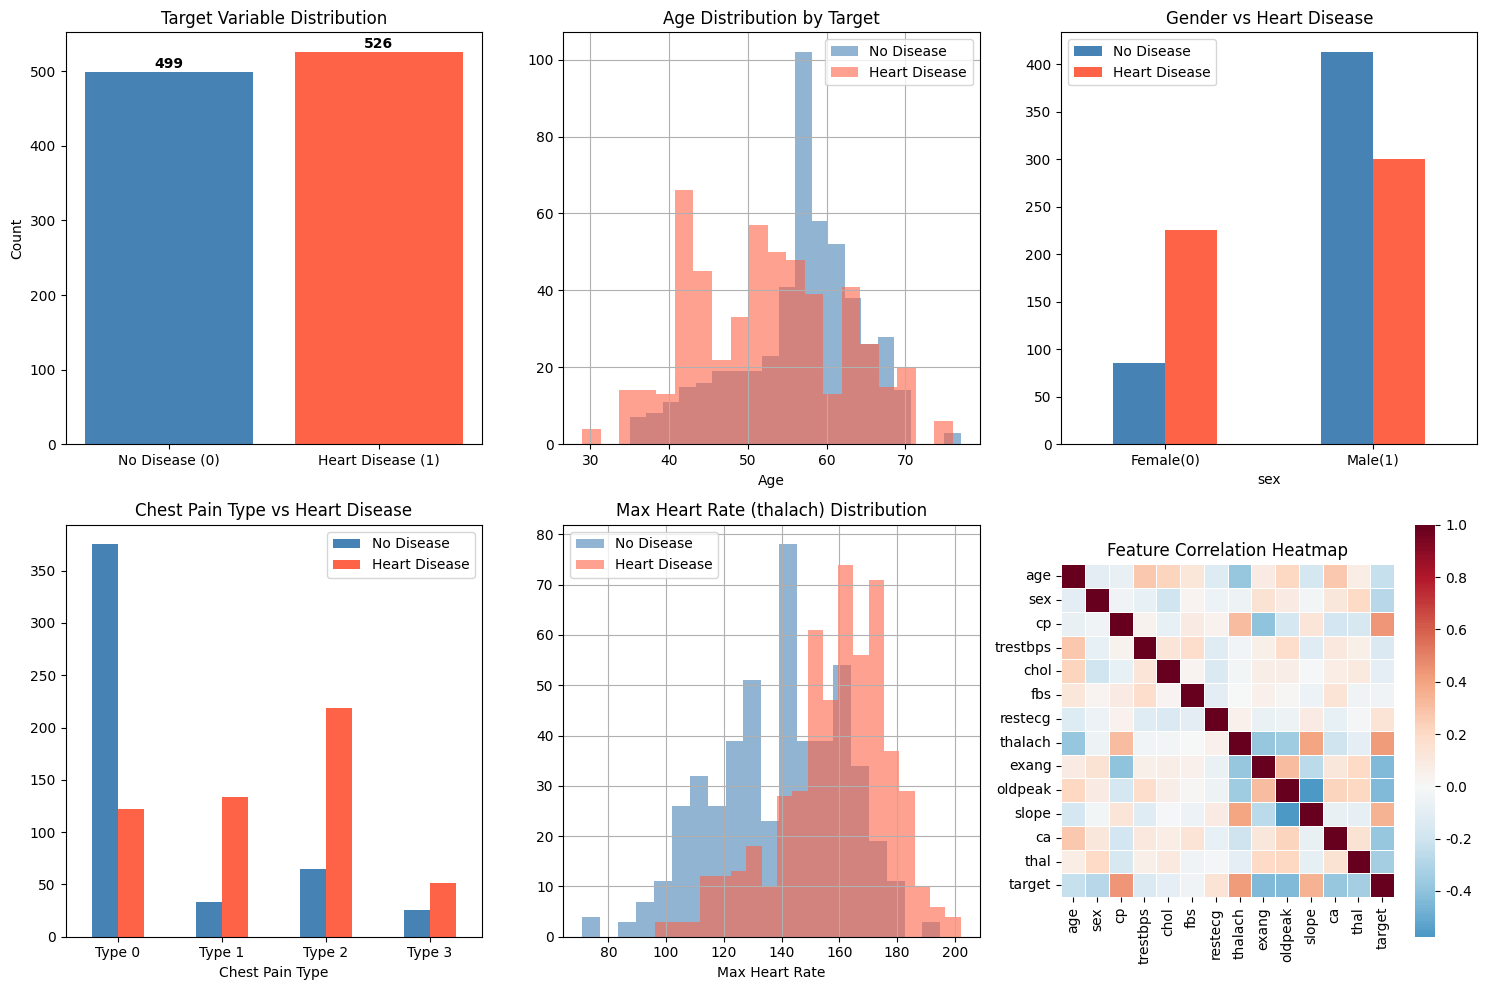

EDA图表已保存为 eda_plots.png


In [22]:
# ============================================================
# Step 2: 可视化探索性分析 (EDA)
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. 目标变量分布
axes[0,0].bar(['No Disease (0)', 'Heart Disease (1)'],
               df['target'].value_counts().sort_index(),
               color=['steelblue', 'tomato'])
axes[0,0].set_title('Target Variable Distribution')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(df['target'].value_counts().sort_index()):
    axes[0,0].text(i, v+5, str(v), ha='center', fontweight='bold')

# 2. 年龄分布（按患病/未患病）
df[df['target']==0]['age'].hist(ax=axes[0,1], alpha=0.6, label='No Disease', color='steelblue', bins=20)
df[df['target']==1]['age'].hist(ax=axes[0,1], alpha=0.6, label='Heart Disease', color='tomato', bins=20)
axes[0,1].set_title('Age Distribution by Target')
axes[0,1].set_xlabel('Age')
axes[0,1].legend()

# 3. 性别与患病关系
sex_target = df.groupby(['sex', 'target']).size().unstack()
sex_target.plot(kind='bar', ax=axes[0,2], color=['steelblue', 'tomato'])
axes[0,2].set_title('Gender vs Heart Disease')
axes[0,2].set_xticklabels(['Female(0)', 'Male(1)'], rotation=0)
axes[0,2].legend(['No Disease', 'Heart Disease'])

# 4. 胸痛类型与患病关系
cp_target = df.groupby(['cp', 'target']).size().unstack()
cp_target.plot(kind='bar', ax=axes[1,0], color=['steelblue', 'tomato'])
axes[1,0].set_title('Chest Pain Type vs Heart Disease')
axes[1,0].set_xlabel('Chest Pain Type')
axes[1,0].set_xticklabels(['Type 0','Type 1','Type 2','Type 3'], rotation=0)
axes[1,0].legend(['No Disease', 'Heart Disease'])

# 5. 最大心率分布
df[df['target']==0]['thalach'].hist(ax=axes[1,1], alpha=0.6, label='No Disease', color='steelblue', bins=20)
df[df['target']==1]['thalach'].hist(ax=axes[1,1], alpha=0.6, label='Heart Disease', color='tomato', bins=20)
axes[1,1].set_title('Max Heart Rate (thalach) Distribution')
axes[1,1].set_xlabel('Max Heart Rate')
axes[1,1].legend()

# 6. 相关性热力图
corr = df.corr()
sns.heatmap(corr, ax=axes[1,2], cmap='RdBu_r', center=0,
            annot=False, square=True, linewidths=0.5)
axes[1,2].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA图表已保存为 eda_plots.png")


In [23]:
# ============================================================
# Step 3: 数据预处理 + 模型训练（使用去重后数据）
# ============================================================
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, RocCurveDisplay,
                              PrecisionRecallDisplay, f1_score)
import warnings
warnings.filterwarnings('ignore')

# 使用去重后的数据
X = df_clean.drop('target', axis=1)
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")
print(f"训练集类别分布: {y_train.value_counts().to_dict()}")

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"\nSMOTE后训练集: {X_train_res.shape}")
print(f"SMOTE后类别分布: {dict(zip(*__import__('numpy').unique(y_train_res, return_counts=True)))}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('rfe', RFE(LogisticRegression(max_iter=1000, random_state=42), n_features_to_select=8)),
            ('clf', LogisticRegression(max_iter=1000, random_state=42))
        ]),
        'params': {
            'clf__C': [0.01, 0.1, 1, 10],
            'clf__penalty': ['l1', 'l2'],
            'clf__solver': ['liblinear']
        }
    },
    'Random Forest': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('rfe', RFE(RandomForestClassifier(n_estimators=50, random_state=42), n_features_to_select=8)),
            ('clf', RandomForestClassifier(random_state=42))
        ]),
        'params': {
            'clf__n_estimators': [100, 200],
            'clf__max_depth': [None, 5, 10],
            'clf__min_samples_split': [2, 5]
        }
    },
    'XGBoost': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('rfe', RFE(XGBClassifier(n_estimators=50, random_state=42, eval_metric='logloss'), n_features_to_select=8)),
            ('clf', XGBClassifier(random_state=42, eval_metric='logloss'))
        ]),
        'params': {
            'clf__n_estimators': [100, 200],
            'clf__max_depth': [3, 5, 7],
            'clf__learning_rate': [0.01, 0.1]
        }
    },
    'SVM': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('rfe', RFE(LogisticRegression(max_iter=1000, random_state=42), n_features_to_select=8)),
            ('clf', SVC(probability=True, random_state=42))
        ]),
        'params': {
            'clf__C': [0.1, 1, 10],
            'clf__kernel': ['rbf', 'linear'],
            'clf__gamma': ['scale', 'auto']
        }
    }
}

print("\n开始训练（约需1-2分钟）...")
results = {}
best_models = {}

for name, config in models.items():
    print(f"  训练 {name}...")
    gs = GridSearchCV(config['pipeline'], config['params'],
                      cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
    gs.fit(X_train_res, y_train_res)

    y_pred = gs.predict(X_test)
    y_prob = gs.predict_proba(X_test)[:, 1]

    results[name] = {
        'best_params': gs.best_params_,
        'cv_auc': gs.best_score_,
        'test_auc': roc_auc_score(y_test, y_prob),
        'test_f1': f1_score(y_test, y_pred),
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    best_models[name] = gs.best_estimator_
    print(f"    CV AUC: {gs.best_score_:.4f} | Test AUC: {results[name]['test_auc']:.4f} | Test F1: {results[name]['test_f1']:.4f}")

print("\n训练完成!")


训练集: (241, 13), 测试集: (61, 13)
训练集类别分布: {1: 131, 0: 110}

SMOTE后训练集: (262, 13)
SMOTE后类别分布: {np.int64(0): np.int64(131), np.int64(1): np.int64(131)}

开始训练（约需1-2分钟）...
  训练 Logistic Regression...
    CV AUC: 0.9137 | Test AUC: 0.8734 | Test F1: 0.7619
  训练 Random Forest...
    CV AUC: 0.9134 | Test AUC: 0.8474 | Test F1: 0.7761
  训练 XGBoost...
    CV AUC: 0.9167 | Test AUC: 0.8945 | Test F1: 0.8116
  训练 SVM...
    CV AUC: 0.9129 | Test AUC: 0.8528 | Test F1: 0.8358

训练完成!


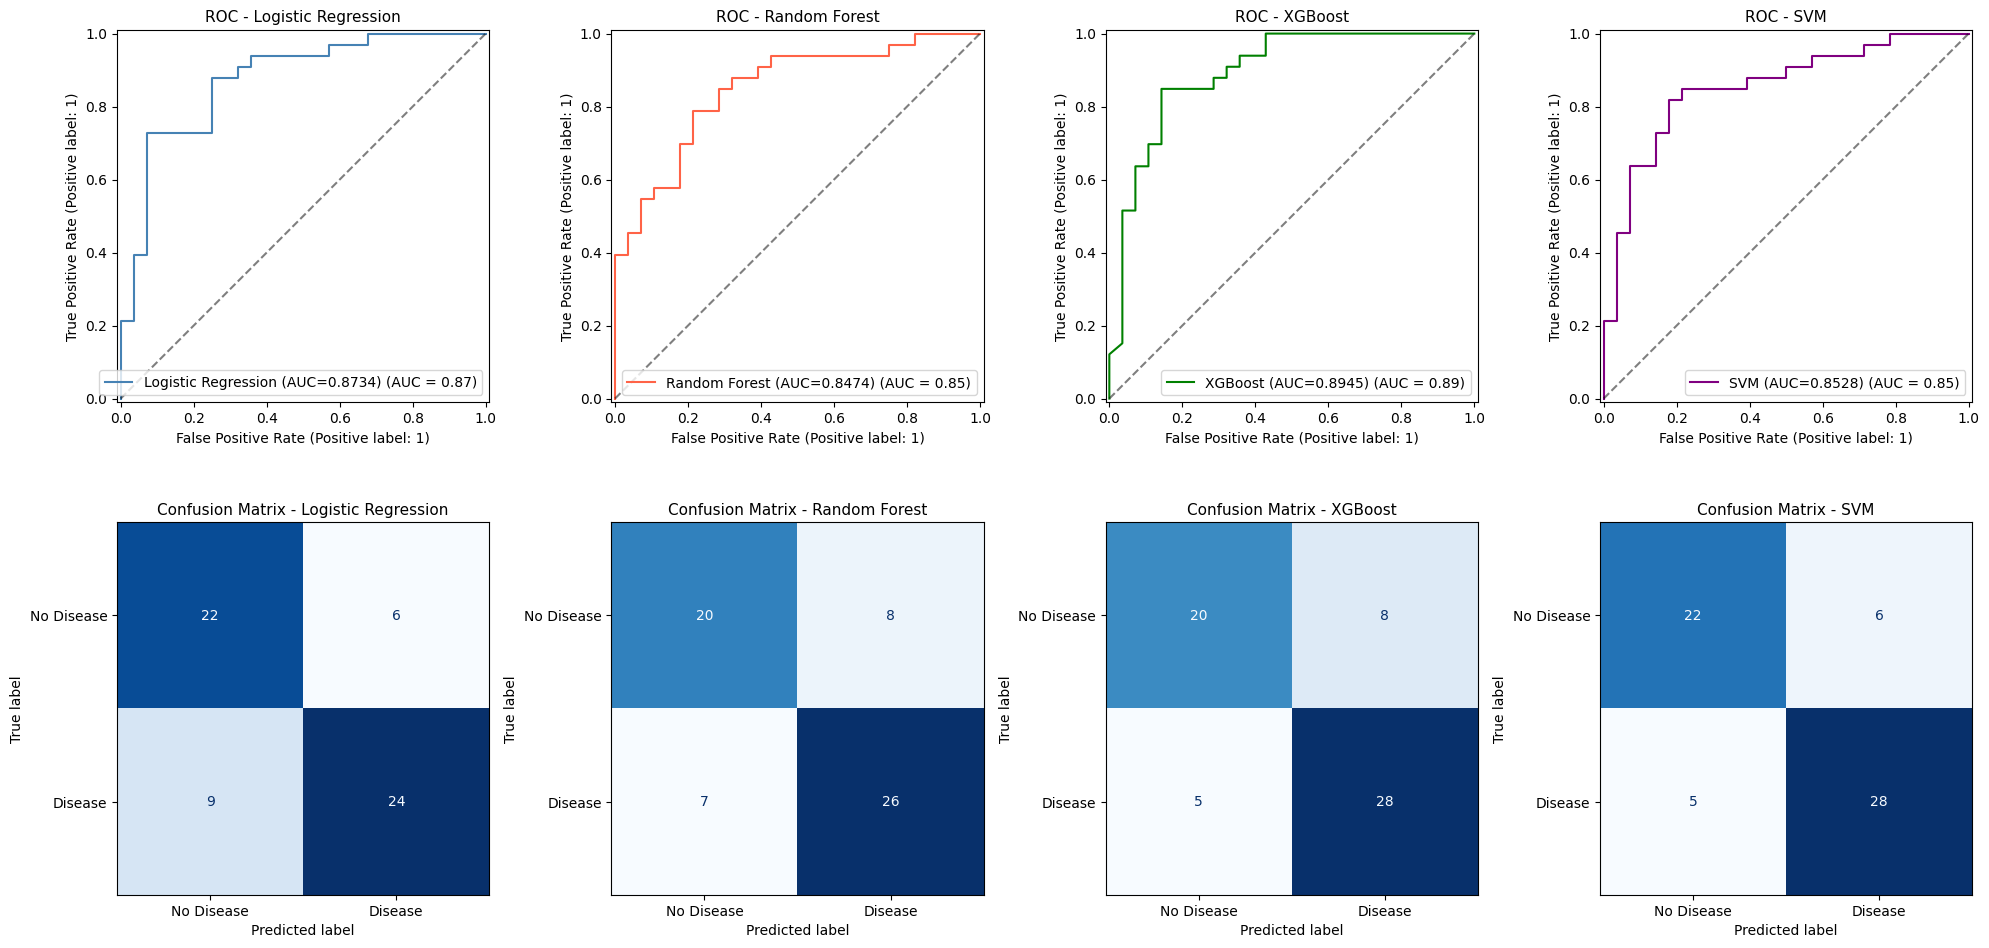


=== 模型性能汇总 ===
Model                    CV AUC   Test AUC   Test F1
----------------------------------------------------
Logistic Regression      0.9137     0.8734    0.7619
Random Forest            0.9134     0.8474    0.7761
XGBoost                  0.9167     0.8945    0.8116
SVM                      0.9129     0.8528    0.8358


In [24]:
# ============================================================
# Step 4: 评估可视化（ROC曲线 + 混淆矩阵）
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
colors = ['steelblue', 'tomato', 'green', 'purple']

for i, (name, res) in enumerate(results.items()):
    RocCurveDisplay.from_predictions(
        y_test, res['y_prob'],
        name=f"{name} (AUC={res['test_auc']:.4f})",
        ax=axes[0, i], color=colors[i]
    )
    axes[0, i].plot([0,1],[0,1],'k--', alpha=0.5)
    axes[0, i].set_title(f'ROC - {name}', fontsize=11)

    ConfusionMatrixDisplay.from_predictions(
        y_test, res['y_pred'],
        ax=axes[1, i], colorbar=False,
        display_labels=['No Disease', 'Disease'],
        cmap='Blues'
    )
    axes[1, i].set_title(f'Confusion Matrix - {name}', fontsize=11)

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== 模型性能汇总 ===")
print(f"{'Model':<22} {'CV AUC':>8} {'Test AUC':>10} {'Test F1':>9}")
print("-" * 52)
for name, res in results.items():
    print(f"{name:<22} {res['cv_auc']:>8.4f} {res['test_auc']:>10.4f} {res['test_f1']:>9.4f}")


RFE选中的特征 (8个): ['sex', 'cp', 'restecg', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


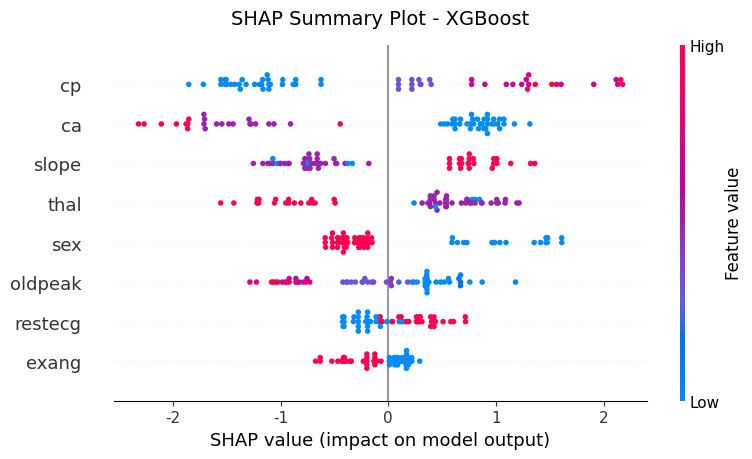

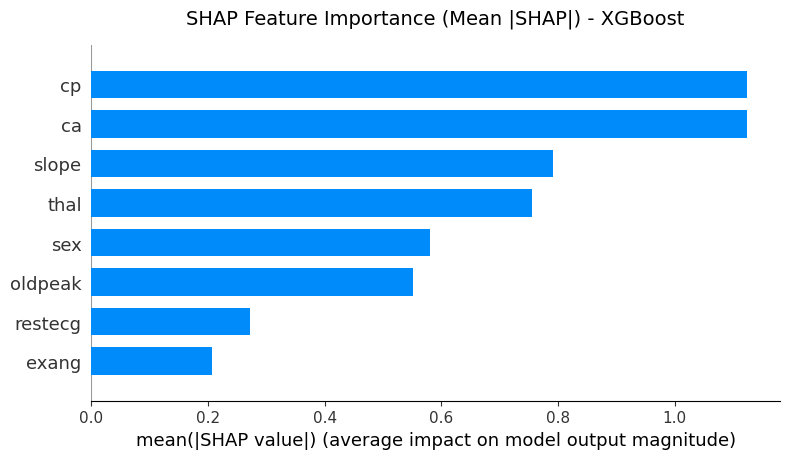


单样本解释 - 实际标签: 0, 预测概率: 0.0249


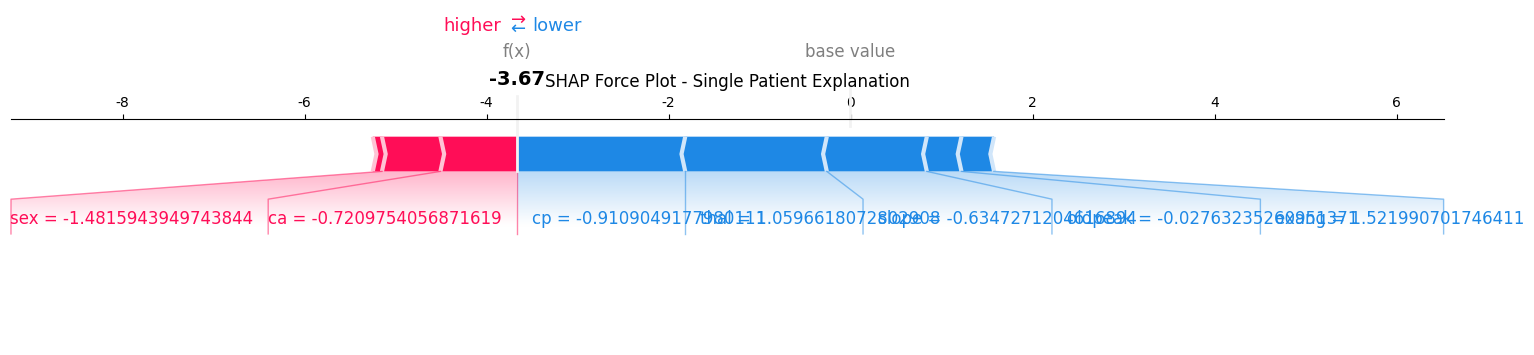


SHAP分析完成！


In [25]:
# ============================================================
# Step 5: SHAP 可解释性分析（核心亮点）
# ============================================================
import shap

# 用XGBoost（最优模型）做SHAP
best_xgb_pipeline = best_models['XGBoost']
xgb_clf = best_xgb_pipeline.named_steps['clf']
rfe = best_xgb_pipeline.named_steps['rfe']
scaler = best_xgb_pipeline.named_steps['scaler']

# 获取RFE选中的特征
X_test_scaled = scaler.transform(X_test)
X_test_rfe = rfe.transform(X_test_scaled)
selected_features = X_test.columns[rfe.support_].tolist()
print(f"RFE选中的特征 ({len(selected_features)}个): {selected_features}")

# 创建SHAP解释器
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test_rfe)

X_test_rfe_df = pd.DataFrame(X_test_rfe, columns=selected_features)

# 图1: SHAP Summary Plot (Beeswarm) - 特征重要性+影响方向
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_rfe_df, show=False)
plt.title('SHAP Summary Plot - XGBoost', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# 图2: SHAP Bar Plot - 平均绝对贡献
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_rfe_df, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP|) - XGBoost', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# 图3: SHAP Force Plot - 单个患者解释（第一个患者）
print(f"\n单样本解释 - 实际标签: {y_test.iloc[0]}, 预测概率: {results['XGBoost']['y_prob'][0]:.4f}")
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_rfe_df.iloc[0],
    matplotlib=True,
    show=False,
    figsize=(16, 4)
)
plt.title('SHAP Force Plot - Single Patient Explanation', fontsize=12)
plt.tight_layout()
plt.savefig('shap_force.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSHAP分析完成！")


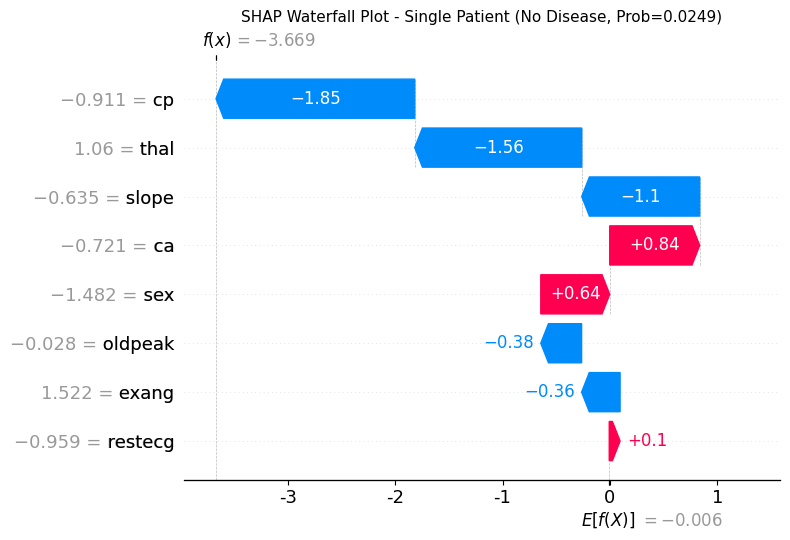

Waterfall图保存完成


In [26]:
# ============================================================
# Step 5补充: SHAP Waterfall Plot（替换Force Plot，更清晰）
# ============================================================
import shap

# 单样本Waterfall图（第一个测试样本）
shap_explanation = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test_rfe_df.iloc[0].values,
    feature_names=selected_features
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation, show=False)
plt.title('SHAP Waterfall Plot - Single Patient (No Disease, Prob=0.0249)', fontsize=11)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall图保存完成")


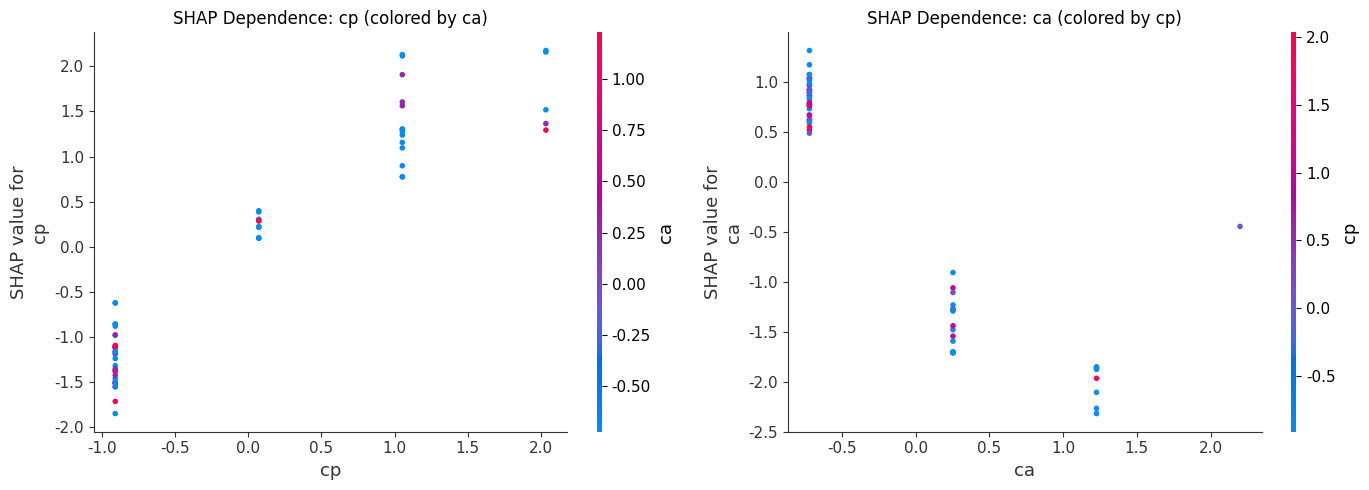

Dependence图保存完成


In [27]:
# ============================================================
# Step 6: SHAP Dependence Plot（特征交互分析）
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# cp 与 ca 的交互（最重要的两个特征）
shap.dependence_plot(
    'cp', shap_values, X_test_rfe_df,
    interaction_index='ca',
    ax=axes[0], show=False
)
axes[0].set_title('SHAP Dependence: cp (colored by ca)', fontsize=12)

# ca 与 cp 的交互
shap.dependence_plot(
    'ca', shap_values, X_test_rfe_df,
    interaction_index='cp',
    ax=axes[1], show=False
)
axes[1].set_title('SHAP Dependence: ca (colored by cp)', fontsize=12)

plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dependence图保存完成")


In [30]:
from sklearn.metrics import precision_score, recall_score

print(f"{'模型':<22} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print('-' * 55)
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    p = precision_score(y_test, y_pred)
    r = recall_score(y_test, y_pred)
    f1 = 2*p*r/(p+r)
    print(f"{name:<22} {p:>10.4f} {r:>10.4f} {f1:>10.4f}")



模型                      Precision     Recall         F1
-------------------------------------------------------
Logistic Regression        0.8000     0.7273     0.7619
Random Forest              0.7647     0.7879     0.7761
XGBoost                    0.7778     0.8485     0.8116
SVM                        0.8235     0.8485     0.8358
